# 01 — Exploratory Data Analysis

**Project:** Hospital Readmission Prediction  
**Dataset:** `hospital_readmissions.csv` (25,000 rows × 17 columns)  
**Target:** `readmitted` — `yes`→1, `no`→0 | positive rate ≈ 45.3%

| # | Section |
|---|---|
| 1 | Environment setup |
| 2 | Load config + raw data |
| 3 | Initial inspection |
| 4 | Missing-value analysis |
| 5 | Class (outcome) distribution |
| 6 | Age bracket distribution |
| 7 | Numeric feature distributions |
| 8 | Categorical feature distributions |
| 9 | medical_specialty — missingness analysis |
| 10 | Prior utilisation distributions |
| 11 | Relationships with the target |
| 12 | Correlation matrix |
| 13 | Takeaways |

---
## 1 — Environment setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils import load_config, get_logger, set_seed

logger = get_logger('01_eda')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
FIGURES = ROOT / 'reports' / 'figures' / 'eda'
FIGURES.mkdir(parents=True, exist_ok=True)

print(f'ROOT: {ROOT}')
print('Environment ready.')

ROOT: C:\Users\speak\HA_Project\Hospital-Readmission-Project-
Environment ready.


---
## 2 — Load config and raw data

In [2]:
config = load_config(ROOT / 'config' / 'config.yaml')
set_seed(config['random_seed'])

TARGET   = config['data']['target_column']
raw_path = ROOT / config['paths']['raw_data']

print(f'Raw data : {raw_path}')
print(f'Target   : {TARGET}')

Raw data : C:\Users\speak\HA_Project\Hospital-Readmission-Project-\data\raw\hospital_readmissions.csv
Target   : readmitted


In [3]:
from src.data_preparation import load_raw_data

df = load_raw_data(raw_path)
df.head()

2026-03-11 22:34:10 | INFO     | src.data_preparation | Loading raw data from C:\Users\speak\HA_Project\Hospital-Readmission-Project-\data\raw\hospital_readmissions.csv


2026-03-11 22:34:10 | INFO     | src.data_preparation | Loaded 25000 rows × 17 columns


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


---
## 3 — Initial inspection

In [4]:
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n')
df.info()

Shape: 25,000 rows × 17 columns

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                25000 non-null  str  
 1   time_in_hospital   25000 non-null  int64
 2   n_lab_procedures   25000 non-null  int64
 3   n_procedures       25000 non-null  int64
 4   n_medications      25000 non-null  int64
 5   n_outpatient       25000 non-null  int64
 6   n_inpatient        25000 non-null  int64
 7   n_emergency        25000 non-null  int64
 8   medical_specialty  25000 non-null  str  
 9   diag_1             25000 non-null  str  
 10  diag_2             25000 non-null  str  
 11  diag_3             25000 non-null  str  
 12  glucose_test       25000 non-null  str  
 13  A1Ctest            25000 non-null  str  
 14  change             25000 non-null  str  
 15  diabetes_med       25000 non-null  str  
 16  readmitted         25000 non-null  s

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,25000,6,[70-80),6837,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_in_hospital,25000.0,NaN,NaN,NaN,4.45332,3.00147,1.0,2.0,4.0,6.0,14.0
n_lab_procedures,25000.0,NaN,NaN,NaN,43.24076,19.81862,1.0,31.0,44.0,57.0,113.0
n_procedures,25000.0,NaN,NaN,NaN,1.35236,1.715179,0.0,0.0,1.0,2.0,6.0
n_medications,25000.0,NaN,NaN,NaN,16.2524,8.060532,1.0,11.0,15.0,20.0,79.0
n_outpatient,25000.0,NaN,NaN,NaN,0.3664,1.195478,0.0,0.0,0.0,0.0,33.0
n_inpatient,25000.0,NaN,NaN,NaN,0.61596,1.177951,0.0,0.0,0.0,1.0,15.0
n_emergency,25000.0,NaN,NaN,NaN,0.1866,0.885873,0.0,0.0,0.0,0.0,64.0
medical_specialty,25000,7,Missing,12382,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diag_1,25000,8,Circulatory,7824,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 4 — Missing-value analysis

The target column `readmitted` contains `yes`/`no` strings — this is expected and will be mapped to 1/0 by `clean_data()`. The string `"Missing"` in `medical_specialty` is a **valid category**, not a NaN.

In [6]:
# Exclude the target string column from missing-value analysis
non_target = df.drop(columns=[TARGET])
missing = (
    non_target.isna().sum()
      .rename('n_missing')
      .to_frame()
      .assign(pct_missing=lambda x: x['n_missing'] / len(df) * 100)
      .query('n_missing > 0')
      .sort_values('pct_missing', ascending=False)
)

if missing.empty:
    print('No NaN values found in non-target columns. \u2713')
else:
    display(missing)

# Show medical_specialty "Missing" prevalence separately
if 'medical_specialty' in df.columns:
    n_missing_specialty = (df['medical_specialty'] == 'Missing').sum()
    pct = n_missing_specialty / len(df) * 100
    print(f'\nmedical_specialty == "Missing": {n_missing_specialty:,} rows ({pct:.1f}%)')
    print('(This is a valid category, NOT a NaN \u2014 not imputed)')

No NaN values found in non-target columns. ✓

medical_specialty == "Missing": 12,382 rows (49.5%)
(This is a valid category, NOT a NaN — not imputed)


---
## 5 — Class (outcome) distribution

Class distribution (raw strings):

,Count,Pct (%)
readmitted,,
no,13246,53.0
yes,11754,47.0



Positive value: "yes" → 1  |  Positive rate: 47.0%
Class balance is nearly 45/55 — no threshold collapse risk.


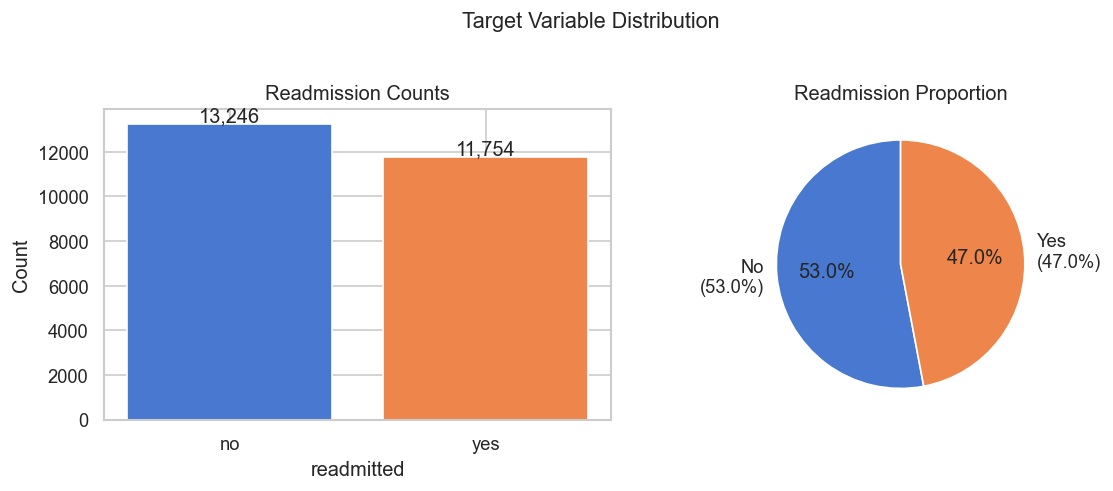

In [7]:
pos_val = config['data'].get('target_positive_value', 'yes')
counts = df[TARGET].value_counts()
rates  = counts / counts.sum() * 100

summary = pd.DataFrame({'Count': counts, 'Pct (%)': rates.round(1)})
summary.index.name = TARGET
print('Class distribution (raw strings):')
display(summary)
print(f'\nPositive value: "{pos_val}" \u2192 1  |  Positive rate: {rates.get(pos_val, 0):.1f}%')
print('Class balance is nearly 45/55 \u2014 no threshold collapse risk.')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

bar_colors = sns.color_palette('muted', 2)
axes[0].bar(counts.index.astype(str), counts.values, color=bar_colors)
axes[0].set_title('Readmission Counts')
axes[0].set_xlabel(f'{TARGET}')
axes[0].set_ylabel('Count')
for label, v in zip(counts.index, counts.values):
    axes[0].text(str(label), v + counts.max() * 0.01, f'{v:,}', ha='center')

labels_pie = [f'No\n({rates.get("no", 0):.1f}%)', f'Yes\n({rates.get("yes", 0):.1f}%)']
axes[1].pie(counts.values, labels=labels_pie, colors=bar_colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Readmission Proportion')

plt.suptitle('Target Variable Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'class_distribution.png', bbox_inches='tight')
plt.show()

---
## 6 — Age bracket distribution

The `age` column contains ordered bracket strings. These will be converted to an ordinal integer (1–6) by `_map_age_to_ordinal()` in feature engineering.

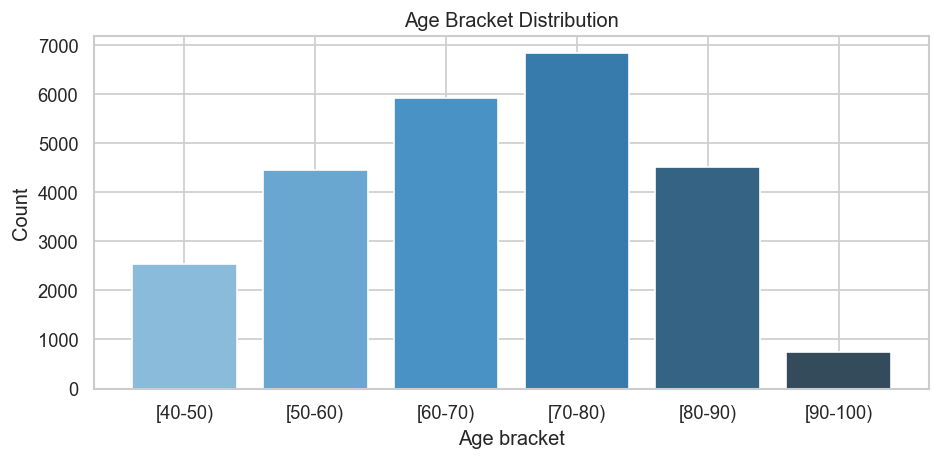

Readmission rate by age bracket:
age
[40-50)     0.445103
[50-60)     0.441599
[60-70)     0.468459
[70-80)     0.487933
[80-90)     0.495793
[90-100)    0.421333


In [8]:
age_order = ['[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

if 'age' in df.columns:
    age_counts = df['age'].value_counts().reindex(age_order, fill_value=0)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(age_counts.index, age_counts.values, color=sns.color_palette('Blues_d', len(age_order)))
    ax.set_xlabel('Age bracket')
    ax.set_ylabel('Count')
    ax.set_title('Age Bracket Distribution')
    plt.tight_layout()
    plt.savefig(FIGURES / 'age_distribution.png', bbox_inches='tight')
    plt.show()

    # Readmission rate by age bracket
    rate_by_age = df.groupby('age')[TARGET].apply(lambda s: (s == 'yes').mean()).reindex(age_order)
    print('Readmission rate by age bracket:')
    print(rate_by_age.to_string())

---
## 7 — Numeric feature distributions

Numeric columns (7): ['time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency']


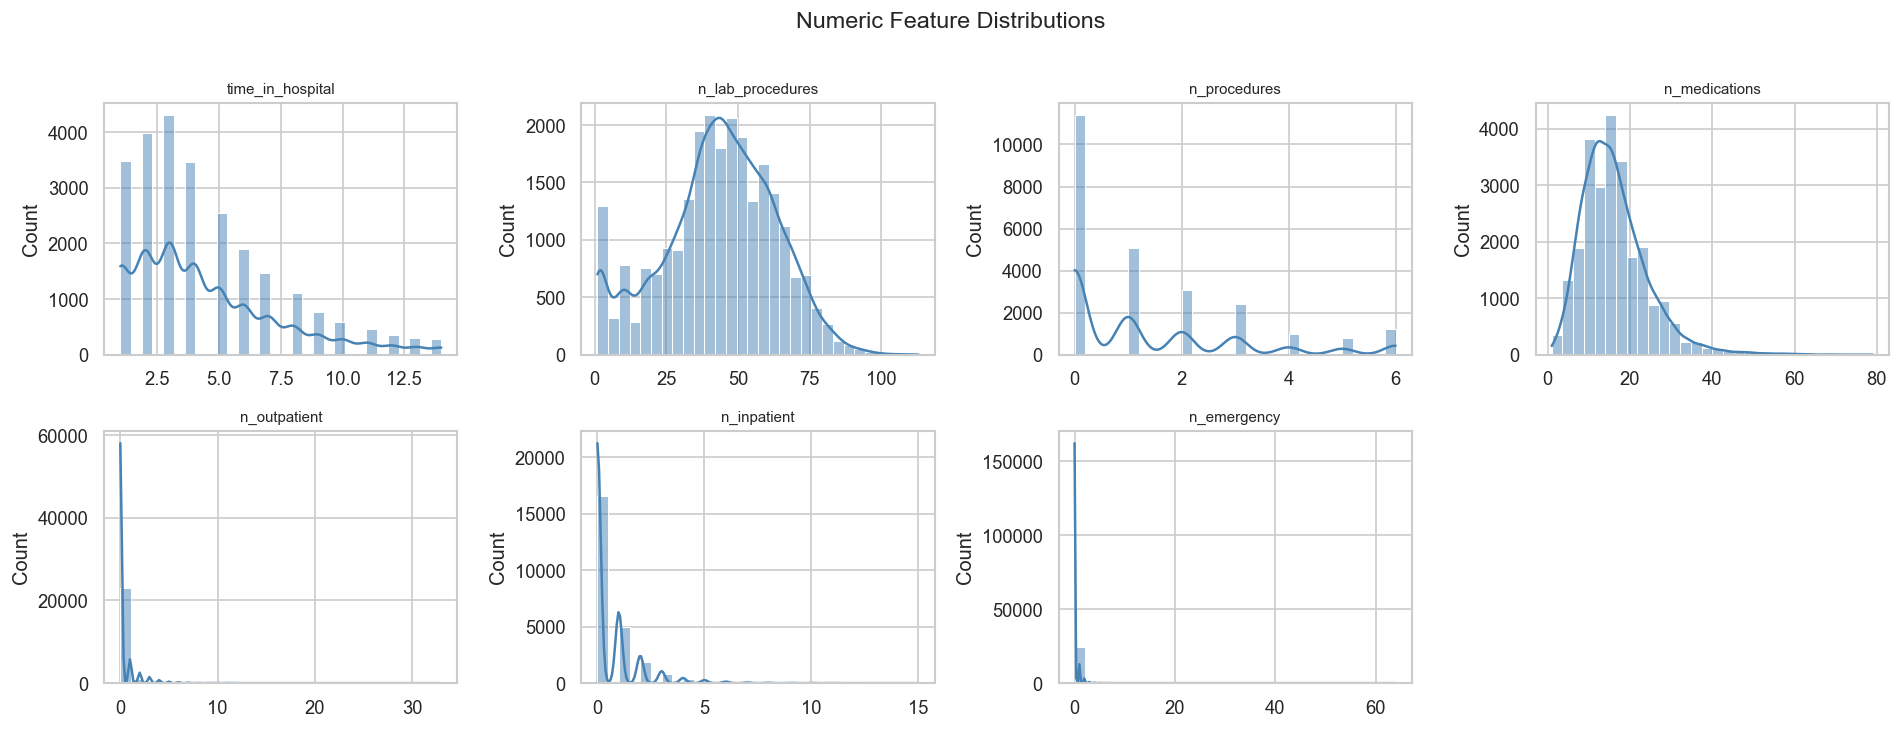

In [9]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print(f'Numeric columns ({len(numeric_cols)}): {numeric_cols}')

if numeric_cols:
    n_cols = 4
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col].dropna(), ax=axes[i], kde=True, bins=30, color='steelblue')
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel('')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Numeric Feature Distributions', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES / 'numeric_distributions.png', bbox_inches='tight')
    plt.show()

---
## 8 — Categorical feature distributions

Categorical columns (9): ['A1Ctest', 'age', 'change', 'diabetes_med', 'diag_1', 'diag_2', 'diag_3', 'glucose_test', 'medical_specialty']


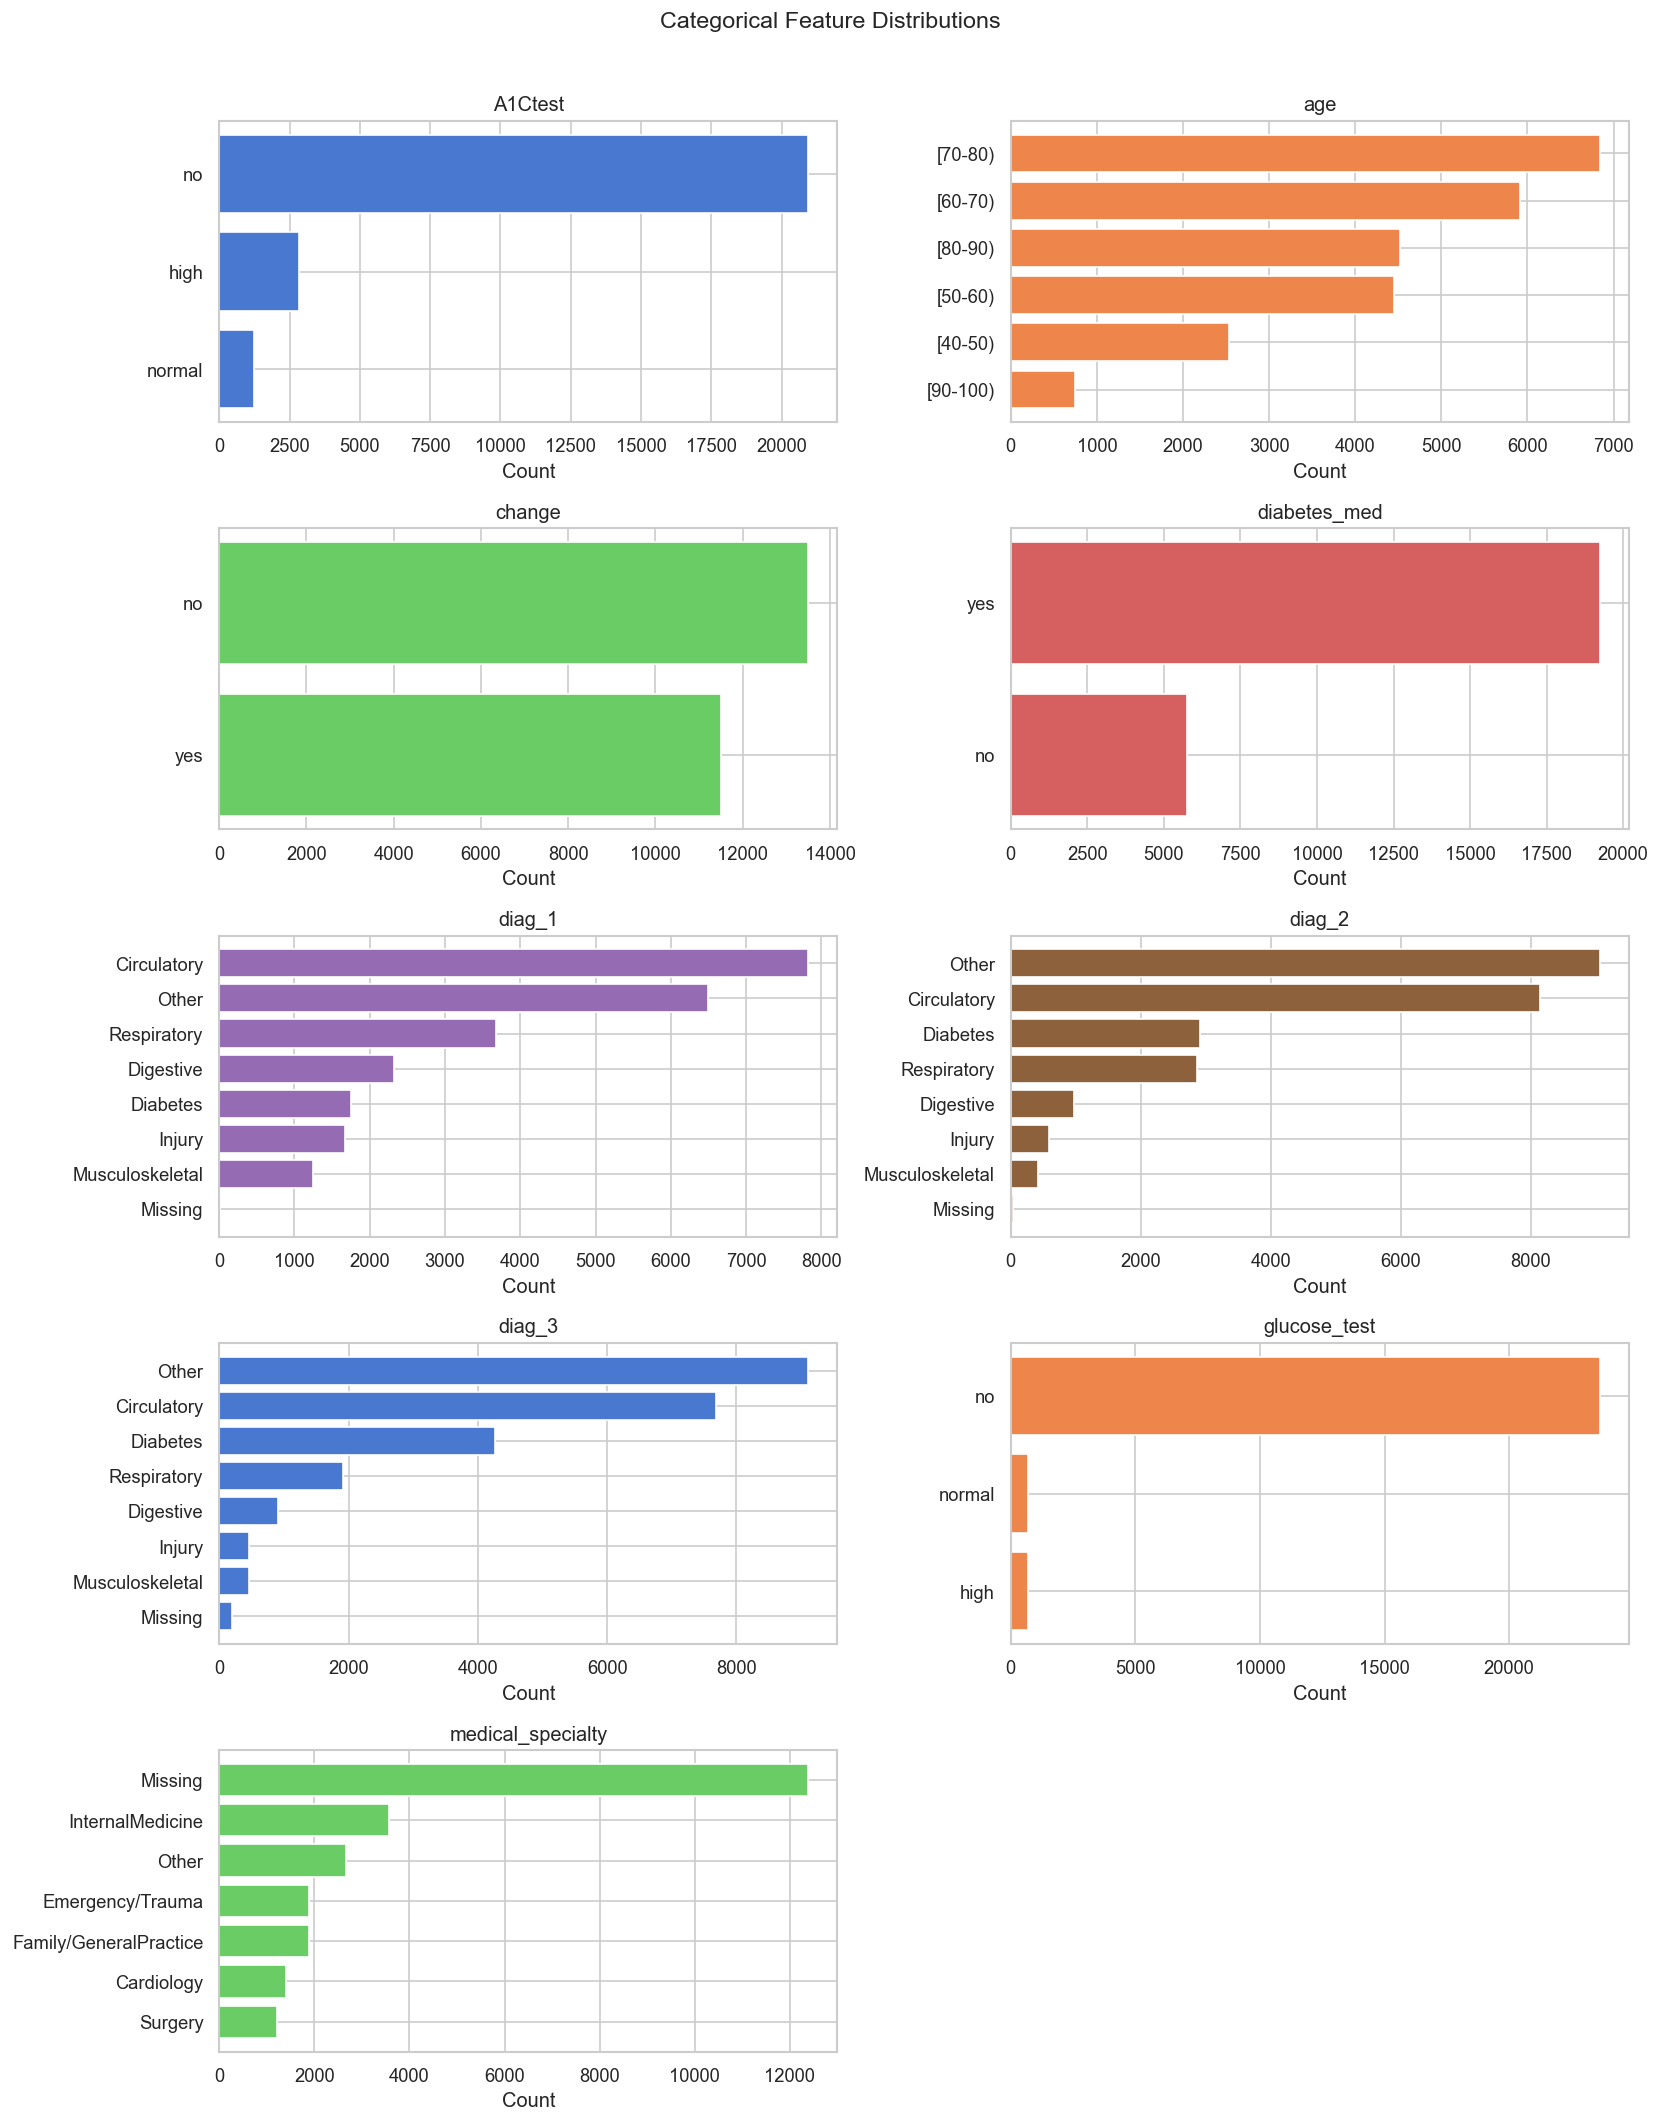

In [10]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.difference([TARGET]).tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

if cat_cols:
    n_cols = 2
    n_rows = int(np.ceil(len(cat_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cat_cols):
        top_vals = df[col].value_counts().head(15)
        axes[i].barh(top_vals.index.astype(str)[::-1], top_vals.values[::-1],
                     color=sns.color_palette('muted')[i % 6])
        axes[i].set_title(col)
        axes[i].set_xlabel('Count')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES / 'categorical_distributions.png', bbox_inches='tight')
    plt.show()

---
## 9 — medical_specialty: missingness analysis

49.5% of records have `medical_specialty == "Missing"`. This is modelled explicitly via `specialty_known` binary flag in feature engineering.

Known specialty: 12,618 (50.5%)
Missing specialty: 12,382 (49.5%)

Top 10 known specialties:
medical_specialty
InternalMedicine          3565
Other                     2664
Emergency/Trauma          1885
Family/GeneralPractice    1882
Cardiology                1409
Surgery                   1213


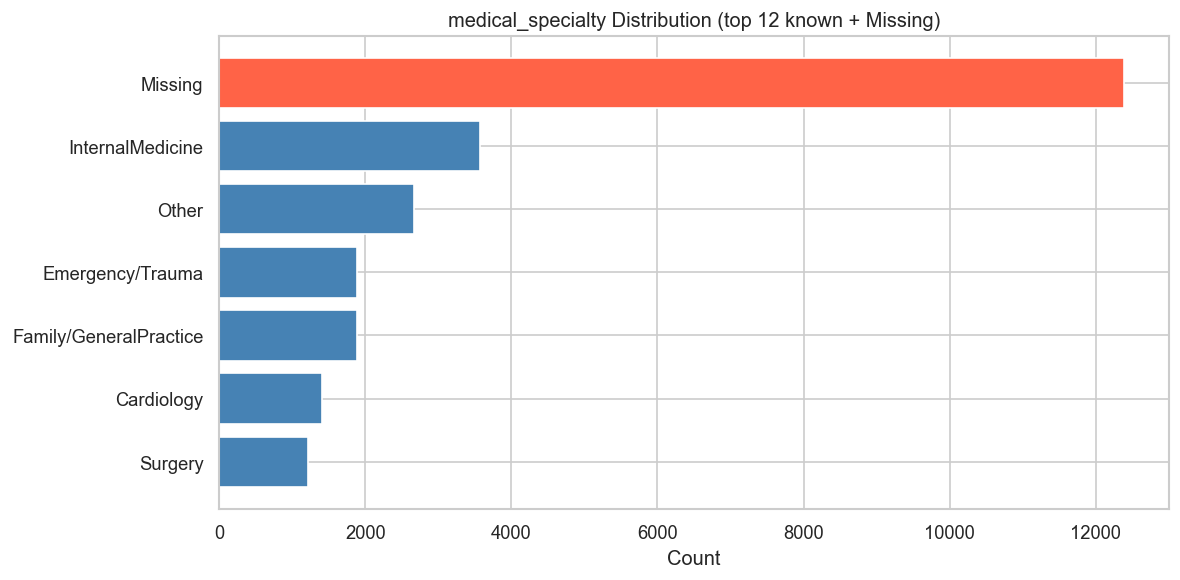

In [11]:
if 'medical_specialty' in df.columns:
    spec_counts = df['medical_specialty'].value_counts()
    known = spec_counts[spec_counts.index != 'Missing'].sort_values(ascending=False)
    unknown = spec_counts.get('Missing', 0)

    print(f'Known specialty: {len(df) - unknown:,} ({(len(df)-unknown)/len(df)*100:.1f}%)')
    print(f'Missing specialty: {unknown:,} ({unknown/len(df)*100:.1f}%)\n')
    print('Top 10 known specialties:')
    print(known.head(10).to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    top_known = known.head(12)
    bars = [('Missing', unknown)] + list(zip(top_known.index, top_known.values))
    labels_b = [b[0] for b in bars]
    values_b = [b[1] for b in bars]
    colors_b = ['tomato'] + ['steelblue'] * len(top_known)
    ax.barh(labels_b[::-1], values_b[::-1], color=colors_b[::-1])
    ax.set_title('medical_specialty Distribution (top 12 known + Missing)')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.savefig(FIGURES / 'medical_specialty_distribution.png', bbox_inches='tight')
    plt.show()

---
## 10 — Prior utilisation distributions

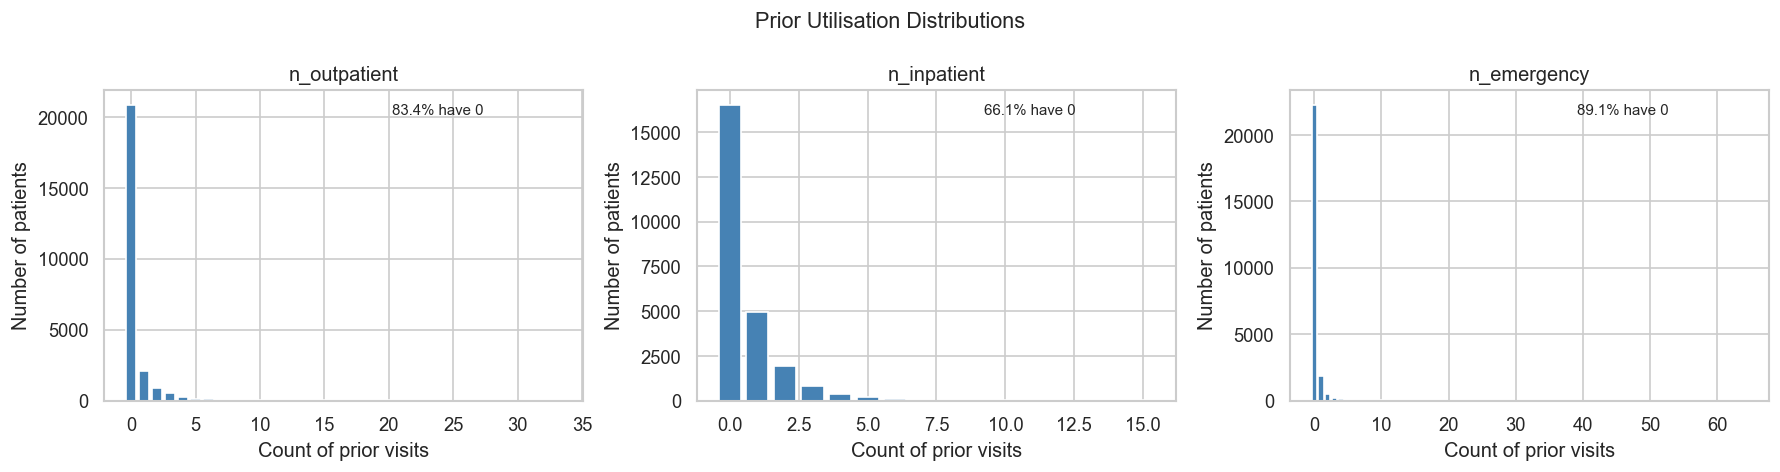

In [12]:
util_cols = [c for c in ['n_outpatient', 'n_inpatient', 'n_emergency'] if c in df.columns]

if util_cols:
    fig, axes = plt.subplots(1, len(util_cols), figsize=(5 * len(util_cols), 4))
    if len(util_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, util_cols):
        counts_col = df[col].value_counts().sort_index()
        ax.bar(counts_col.index, counts_col.values, color='steelblue')
        ax.set_title(col)
        ax.set_xlabel('Count of prior visits')
        ax.set_ylabel('Number of patients')
        pct_zero = (df[col] == 0).mean() * 100
        ax.text(0.6, 0.92, f'{pct_zero:.1f}% have 0', transform=ax.transAxes, fontsize=9)

    plt.suptitle('Prior Utilisation Distributions', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES / 'prior_utilization_distributions.png', bbox_inches='tight')
    plt.show()

---
## 11 — Relationships with the target

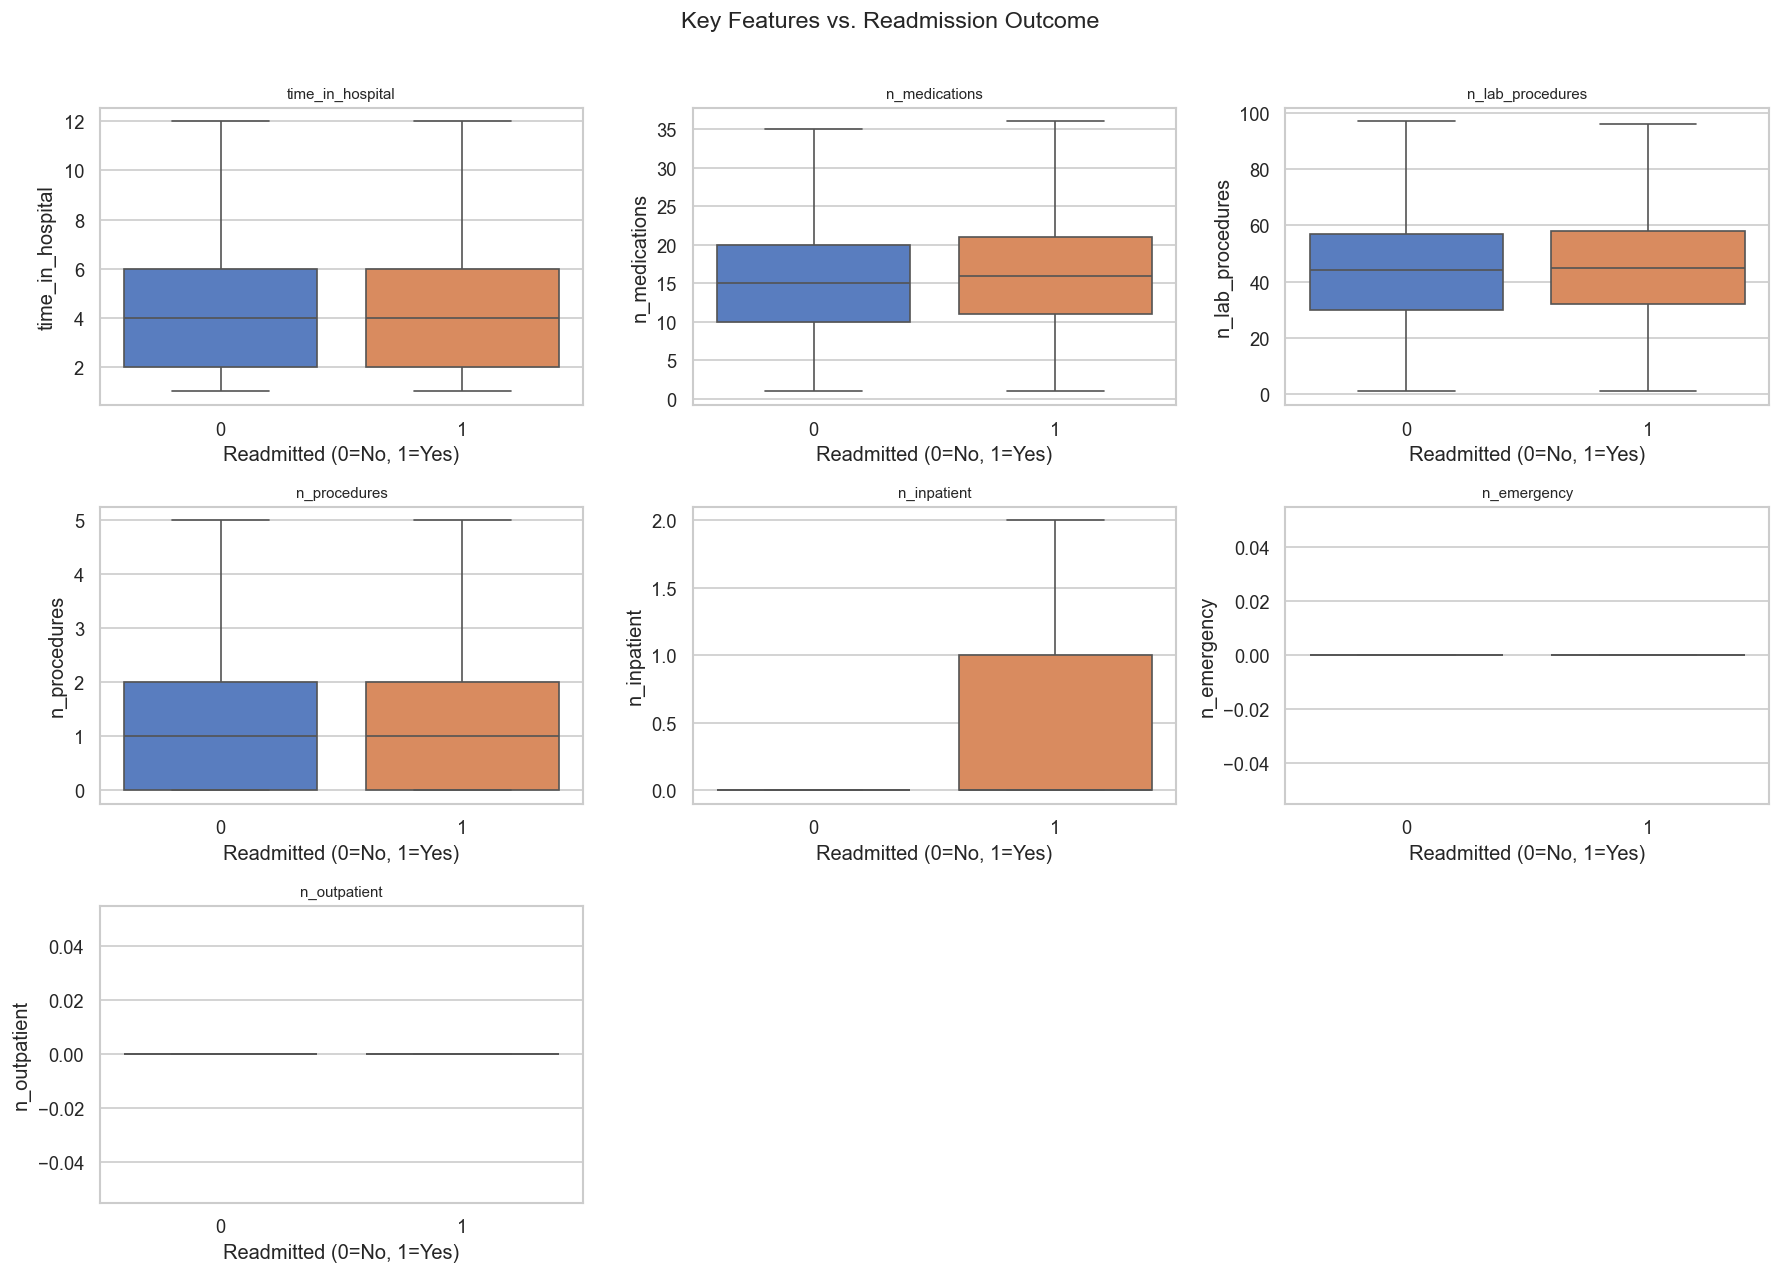

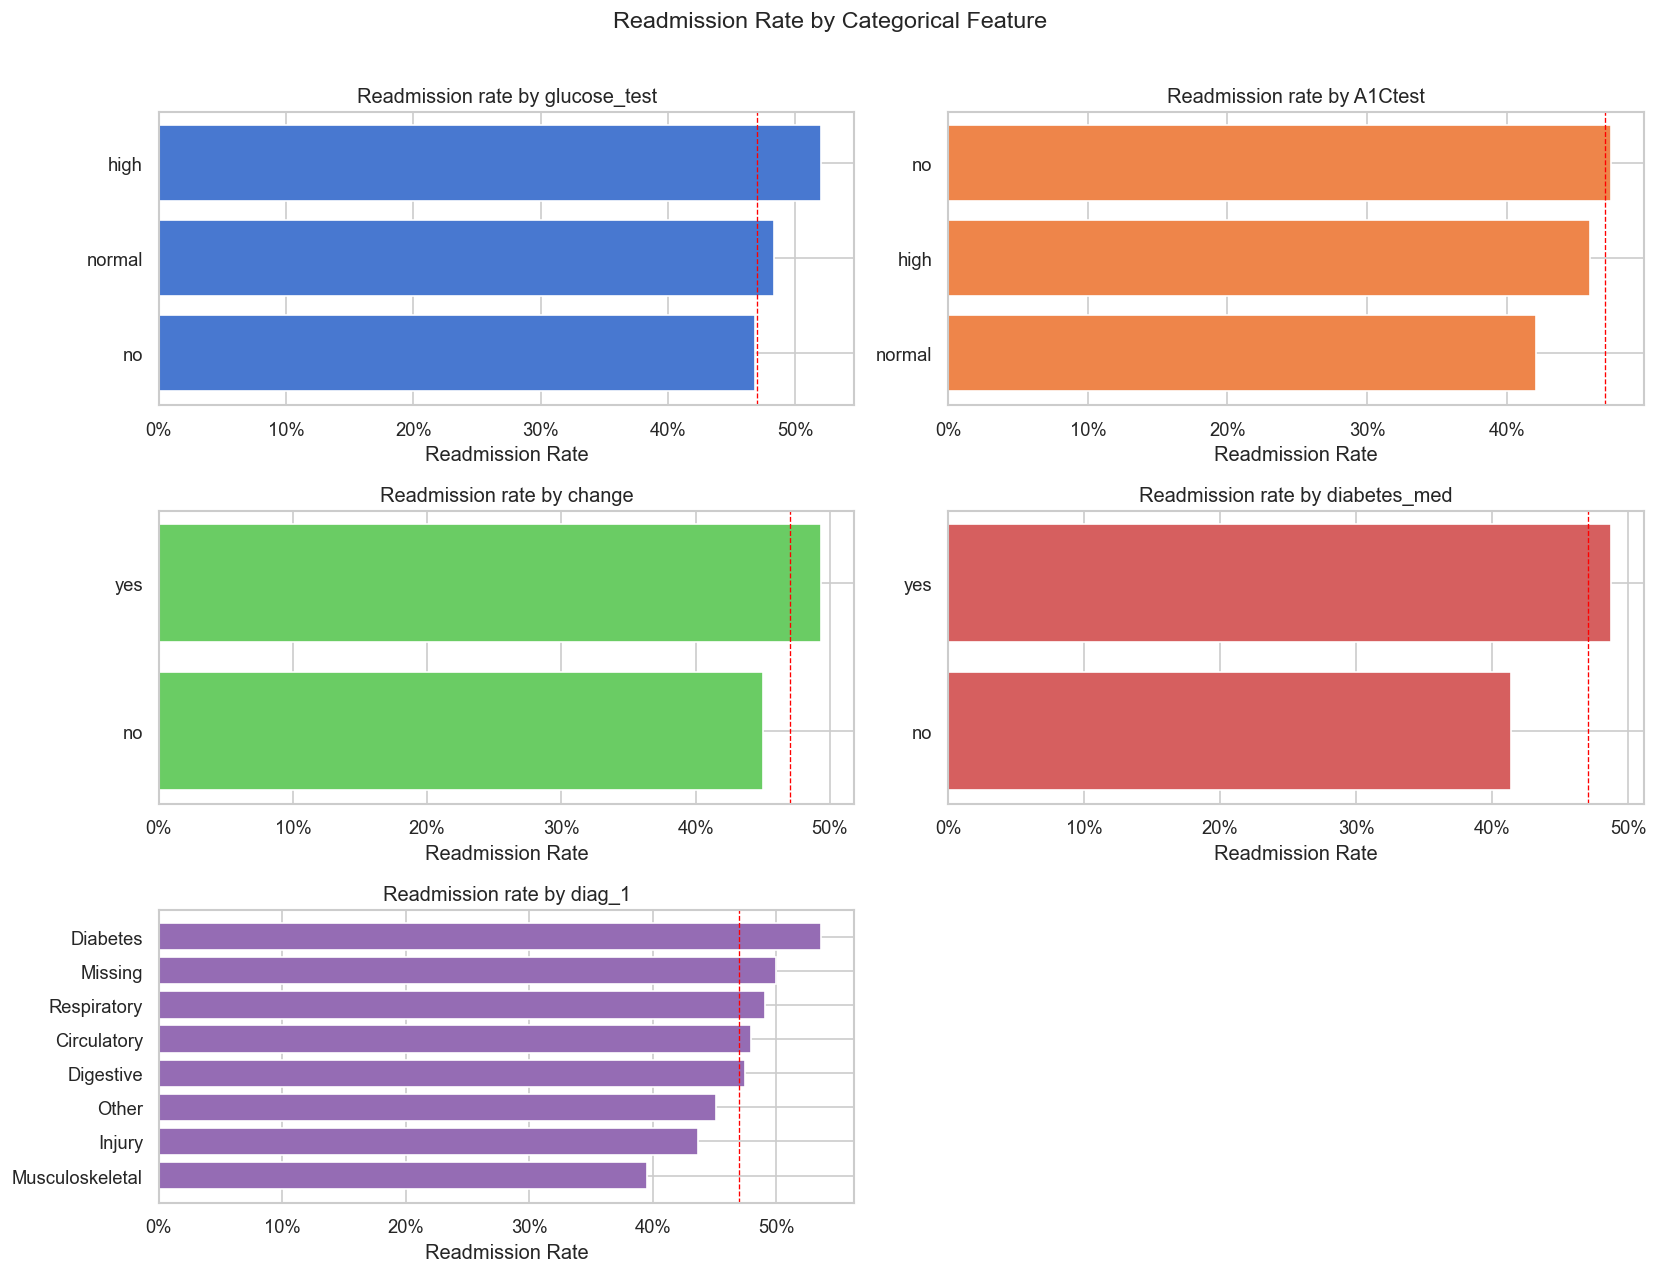

In [13]:
priority_cols = [c for c in [
    'time_in_hospital', 'n_medications', 'n_lab_procedures',
    'n_procedures', 'n_inpatient', 'n_emergency', 'n_outpatient'
] if c in df.columns]

# Map target to numeric for box plots
df_plot = df.copy()
df_plot[TARGET] = (df_plot[TARGET] == 'yes').astype(int)

n_cols = 3
n_rows = int(np.ceil(len(priority_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = np.array(axes).flatten()

for i, col in enumerate(priority_cols):
    sns.boxplot(data=df_plot, x=TARGET, y=col, ax=axes[i],
                palette='muted', showfliers=False)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Readmitted (0=No, 1=Yes)')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Key Features vs. Readmission Outcome', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'features_vs_target.png', bbox_inches='tight')
plt.show()

# Categorical readmission rates
cat_for_rates = [c for c in ['glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'diag_1'] if c in df.columns]
if cat_for_rates:
    n_cols = 2
    n_rows = int(np.ceil(len(cat_for_rates) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cat_for_rates):
        rates_by_cat = df_plot.groupby(col)[TARGET].mean().sort_values(ascending=False)
        axes[i].barh(rates_by_cat.index.astype(str)[::-1], rates_by_cat.values[::-1],
                     color=sns.color_palette('muted')[i % 6])
        axes[i].set_title(f'Readmission rate by {col}')
        axes[i].set_xlabel('Readmission Rate')
        axes[i].axvline(df_plot[TARGET].mean(), color='red', linestyle='--', linewidth=0.8)
        axes[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Readmission Rate by Categorical Feature', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES / 'readmission_rate_by_category.png', bbox_inches='tight')
    plt.show()

---
## 12 — Correlation matrix

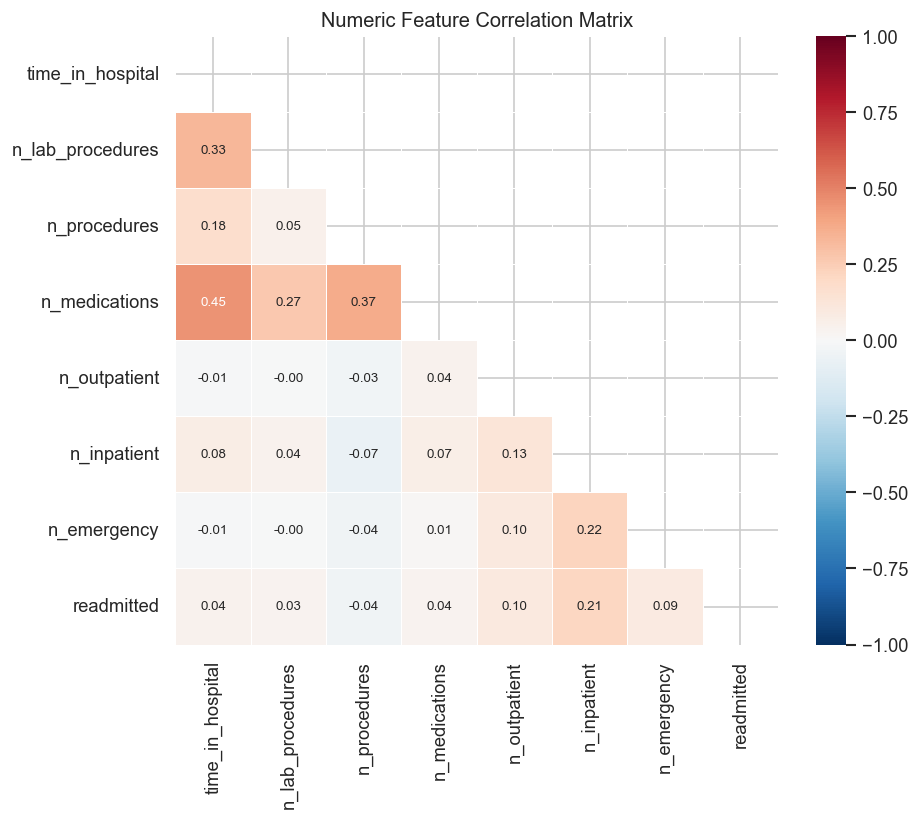

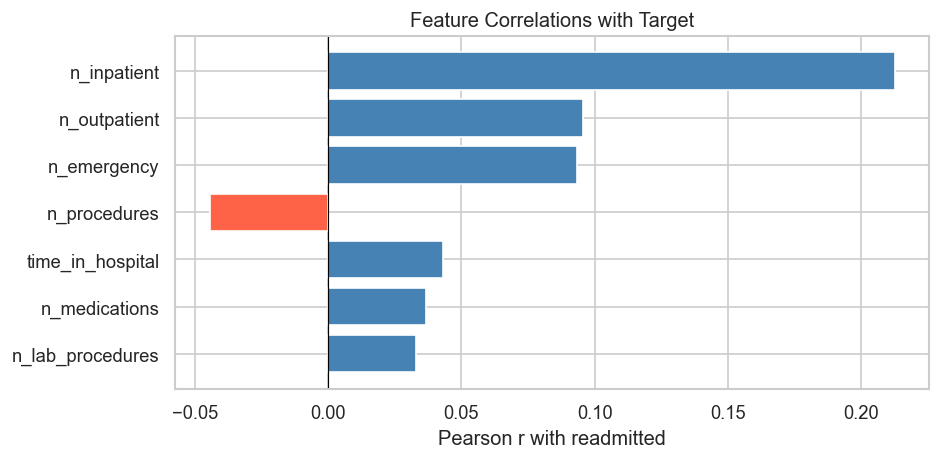

Top correlations with target:
n_inpatient         0.212480
n_outpatient        0.095487
n_emergency         0.093519
n_procedures       -0.044467
time_in_hospital    0.043141
n_medications       0.036871
n_lab_procedures    0.032970


In [14]:
df_num = df_plot.select_dtypes(include='number')
corr = df_num.corr()

fig, ax = plt.subplots(figsize=(max(8, len(df_num.columns)), max(6, len(df_num.columns) - 1)))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.4,
            annot_kws={'size': 8})
ax.set_title('Numeric Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(FIGURES / 'correlation_matrix.png', bbox_inches='tight')
plt.show()

target_corr = (
    df_num.corr()[TARGET]
    .drop(TARGET, errors='ignore')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, max(4, len(target_corr) * 0.35)))
colors = ['tomato' if v < 0 else 'steelblue' for v in target_corr.values]
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.7)
ax.set_xlabel(f'Pearson r with {TARGET}')
ax.set_title('Feature Correlations with Target')
plt.tight_layout()
plt.savefig(FIGURES / 'target_correlations.png', bbox_inches='tight')
plt.show()

print('Top correlations with target:')
print(target_corr.head(10).to_string())

---
## 13 — Takeaways

### Dataset summary
| Property | Value |
|---|---|
| Rows | 25,000 |
| Columns | 17 |
| Target | `readmitted` (yes/no → 1/0) |
| Positive rate | ≈ 45.3% |
| Missing NaN | None (numeric/binary categoricals) |

### Key findings
- **Class balance**: 45/55 split — nearly balanced. No threshold collapse risk. `class_weight='balanced'` remains appropriate but not critical.
- **Age**: categorical brackets `[40-50)` to `[90-100)`. Converted to ordinal integer 1–6 in feature engineering.
- **medical_specialty**: 49.5% "Missing" — modelled as `specialty_known` binary flag.
- **Prior utilisation** (`n_inpatient`, `n_emergency`): sparse counts (majority 0) — `any_n_inpatient` and `any_n_emergency` binary flags created.
- **No leakage columns** — all features are from the admission episode or prior history.

### Next steps
Proceed to `02_modeling_baseline.ipynb`.